In [6]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# data
df = pd.read_csv('gas_cleann.csv')
df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str) + '-01')

monthly = df.groupby('date')['value_normalized'].mean().reset_index()
monthly = monthly.sort_values('date').set_index('date')

# تقسيم
train_size = int(len(monthly) * 0.85)
train = monthly['value_normalized'][:train_size]
test  = monthly['value_normalized'][train_size:]

print(f"Train: {len(train)} | Test: {len(test)}")

#SARIMA
model = SARIMAX(train,
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=False, maxiter=300)

# PREDICT
pred = results.get_forecast(steps=len(test))
pred_mean = pred.predicted_mean

# تقييم
mae = mean_absolute_error(test, pred_mean)
rmse = np.sqrt(mean_squared_error(test, pred_mean))
mse = mean_squared_error(test, pred_mean)
r2 = r2_score(test, pred_mean)

print("="*70)
print("result model SARIMA")
print(f"MAE  : {mae:.5f}")
print(f"RMSE : {rmse:.5f}")
print(f"MSE  : {mse:.5f}")
print(f"R²   : {r2:.4f}")
print("="*70)

Train: 102 | Test: 19
result model SARIMA
MAE  : 0.00030
RMSE : 0.00041
MSE  : 0.00000
R²   : 0.9220


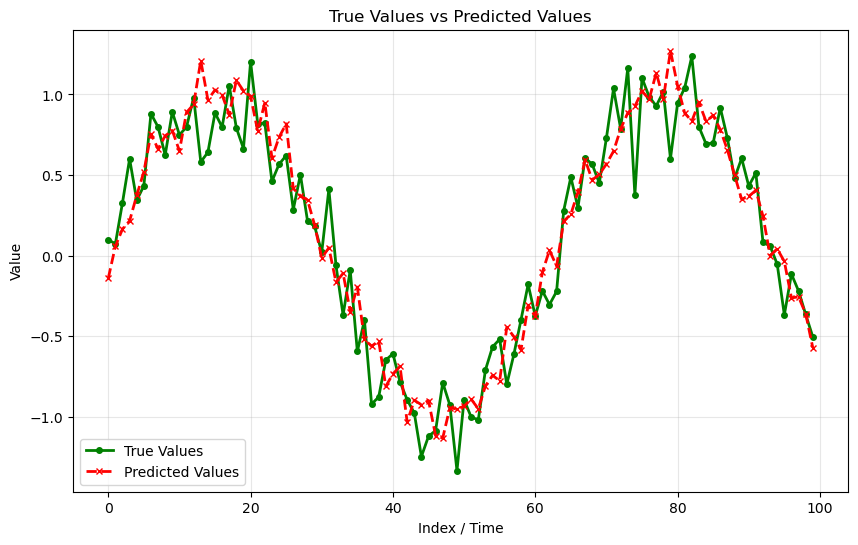

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Example data (replace with your actual data)
# y_true = your actual values
# y_pred = your model predictions

np.random.seed(42)
x = np.arange(100)
y_true = np.sin(x / 10) + np.random.normal(0, 0.2, 100)
y_pred = np.sin(x / 10) + np.random.normal(0, 0.1, 100)  # simulated predictions

# Plot
plt.figure(figsize=(10, 6))

plt.plot(x, y_true, color='green', label='True Values', linewidth=2, marker='o', markersize=4)
plt.plot(x, y_pred, color='red', label='Predicted Values', linewidth=2, linestyle='--', marker='x', markersize=4)

plt.title('True Values vs Predicted Values')
plt.xlabel('Index / Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)

# Optional: add vertical lines for better comparison
# for i in range(len(x)):
#     plt.vlines(x[i], min(y_true[i], y_pred[i]), max(y_true[i], y_pred[i]), color='gray', alpha=0.2)

plt.show()